In [1]:
import archs4py as a4
import pandas as pd
import numpy as np

#path to file
archs4py_file = './data/human_gene_v2.latest (1).h5'
tpm_file = "./data/wget_human_tpm_v2.latest.h5"
raw_counts_file = './data/human_gene_v2.latest.h5'

In [2]:
#a4.ls(archs4py_file)

In [3]:
meta_meta = a4.meta.meta(archs4py_file, "liver", meta_fields=["title", "characteristics_ch1", "source_name_ch1", 'library_source', 'library_strategy', 'molecule_ch1', 'series_id', 'taxid_ch1','geo_accession'])

100%|██████████| 9/9 [00:06<00:00,  1.31it/s]


In [4]:
meta_meta

,title,characteristics_ch1,source_name_ch1,library_source,library_strategy,molecule_ch1,series_id,taxid_ch1,geo_accession
GSM1076108,LSEC,"cell type: Liver sinusoidal endothelial cells,...",LSEC,transcriptomic,RNA-Seq,total RNA,GSE43984,9606,GSM1076108
GSM1101972,Liver,tissue: liver,Biochain:R-1234149-P,transcriptomic,RNA-Seq,total RNA,GSE45326,9606,GSM1101972
GSM1206234,A replicate 1,sample composition: 10 human cell lines (B lym...,Strategene Universal Human Reference RNA (UHRR...,transcriptomic,RNA-Seq,total RNA,"GSE47792,GSE49712",9606,GSM1206234
GSM1206236,A replicate 2,sample composition: 10 human cell lines (B lym...,Strategene Universal Human Reference RNA (UHRR...,transcriptomic,RNA-Seq,total RNA,"GSE47792,GSE49712",9606,GSM1206236
GSM1206238,A replicate 3,sample composition: 10 human cell lines (B lym...,Strategene Universal Human Reference RNA (UHRR...,transcriptomic,RNA-Seq,total RNA,"GSE47792,GSE49712",9606,GSM1206238
...,...,...,...,...,...,...,...,...,...
GSM9470278,1_LX2_Untreated,"tissue: Liver,cell line: LX2,cell type: Epithe...",Liver,transcriptomic,RNA-Seq,total RNA,GSE317347,9606,GSM9470278
GSM9470279,2_LX2_GDF15 treated,"tissue: Liver,cell line: LX2,cell type: Epithe...",Liver,transcriptomic,RNA-Seq,total RNA,GSE317347,9606,GSM9470279
GSM9470280,2_LX2_Untreated,"tissue: Liver,cell line: LX2,cell type: Epithe...",Liver,transcriptomic,RNA-Seq,total RNA,GSE317347,9606,GSM9470280
GSM9470281,3_LX2_GDF15 treated,"tissue: Liver,cell line: LX2,cell type: Epithe...",Liver,transcriptomic,RNA-Seq,total RNA,GSE317347,9606,GSM9470281


In [5]:
#filter on characterristics column as consistently the most extensive metadata 

#take only samples that collected all RNA
meta_subset = meta_meta[meta_meta.molecule_ch1 == 'total RNA']

#convert the fields being filtered on to lower case
meta_subset['characteristics_ch1'] = meta_subset['characteristics_ch1'].str.lower() 
meta_subset['source_name_ch1'] = meta_subset['source_name_ch1'].str.lower() 

#remove cell lines (plural often used)
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('single cell')]
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('cell line')]
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('cell lines')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('cell line')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('cell lines')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('single cell')]

#remove cancer and diseased samples - removed some samples that said 'healthy/disease status: healthy' but too hard to filter for this in all cases
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('cancer')]
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('disease')]
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('tumor')]
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('carcinoma')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('cancer')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('disease')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('tumor')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('carcinoma')]

#wanted just hepatocytes - not endothelial cell samples
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('endothelial')]
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('developmental')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('endothelial')]
meta_subset = meta_subset[~meta_subset.source_name_ch1.str.contains('developmental')]

#too many samples of healty/normal liver didn't specify this in their metadata, just didn't specify a disease
#meta_subset = meta_subset[meta_subset['characteristics_ch1'].str.contains('normal|healthy|Healthy')]

/tmp/ipykernel_3356374/3363582444.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_subset['characteristics_ch1'] = meta_subset['characteristics_ch1'].str.lower()
/tmp/ipykernel_3356374/3363582444.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_subset['source_name_ch1'] = meta_subset['source_name_ch1'].str.lower()


In [6]:
meta_subset_IDs = list(meta_subset.index)

In [7]:
archs4_counts = a4.data.samples(archs4py_file, meta_subset_IDs)

 12%|█▏        | 1044/8762 [00:29<04:17, 29.94it/s]

100%|██████████| 8762/8762 [03:52<00:00, 37.73it/s]


In [8]:
#TPM_counts = a4.data.samples(tpm_file, meta_subset_IDs)

In [9]:
#raw_counts = a4.data.samples(raw_counts_file, meta_subset_IDs)

# Filter Gene Expressions

In [10]:
#filters genes that don't have at least 'readThreshold' reads in 'sampleThreshold' proportion of samples - kept it at default and use only raw counts for the filtering
filtered_exp = a4.utils.filter_genes(archs4_counts, readThreshold=50, sampleThreshold=0.02, deterministic=True, aggregate=True)
#filtered_raw = a4.utils.filter_genes(raw_counts, readThreshold=50, sampleThreshold=0.02, deterministic=True, aggregate=True)

In [11]:
agg_exp = a4.utils.aggregate_duplicate_genes(filtered_exp)
#agg_raw = a4.utils.aggregate_duplicate_genes(filtered_raw)

In [12]:
agg_exp = agg_exp.T
#agg_raw = agg_raw.T

In [13]:
agg_exp = agg_exp[agg_exp.sum(axis=1) >= 100000]
agg_exp.head(n = 5)

#make sure have same raw and log counts
#agg_raw = agg_raw[agg_exp.columns]
#agg_raw = agg_raw.loc[agg_exp.index]

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,AAAS,AACS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
GSM1101972,32,35,17,11998,48,53,26,63,77,344,...,70,2,167,223,190,11,1430,162,1127,1551
GSM1377536,4865,53,33874,51407,45,12,29,209,2331,2261,...,525,444,339,5885,2455,635,6513,22082,6679,3179
GSM1377537,5490,110,18992,34703,47,15,62,334,1821,2566,...,436,365,339,7862,2473,683,5048,31492,5325,2584
GSM1416804,1926,25,1227,7477,15,1,1,12,106,32,...,18,19,16,402,109,5,196,368,163,108
GSM1427132,17,12,0,6,1,2,0,156,1838,1367,...,1167,3264,43,239,845,7,783,2754,1633,1094


In [14]:
agg_exp = np.log10(agg_exp + 1)

In [15]:
agg_exp.head(n=5)

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,AAAS,AACS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
GSM1101972,1.518514,1.556303,1.255273,4.079145,1.690196,1.732394,1.431364,1.806180,1.892095,2.537819,...,1.851258,0.477121,2.225309,2.350248,2.281033,1.079181,3.155640,2.212188,3.052309,3.190892
GSM1377536,3.687172,1.732394,4.529879,4.711031,1.662758,1.113943,1.477121,2.322219,3.367729,3.354493,...,2.720986,2.648360,2.531479,3.769820,3.390228,2.803457,3.813848,4.344058,3.824776,3.502427
GSM1377537,3.739651,2.045323,4.278594,4.540380,1.681241,1.204120,1.799341,2.525045,3.260548,3.409426,...,2.640481,2.563481,2.531479,3.895588,3.393400,2.835056,3.703205,4.498214,3.726401,3.412461
GSM1416804,3.284882,1.414973,3.089198,3.873785,1.204120,0.301030,0.301030,1.113943,2.029384,1.518514,...,1.278754,1.301030,1.230449,2.605305,2.041393,0.778151,2.294466,2.567026,2.214844,2.037426
GSM1427132,1.255273,1.113943,0.000000,0.845098,0.301030,0.477121,0.000000,2.195900,3.264582,3.136086,...,3.067443,3.513883,1.643453,2.380211,2.927370,0.903090,2.894316,3.440122,3.213252,3.039414


In [16]:
#agg_raw.head(n=5)

In [17]:
DATA_ROOT = '../data/Full data files'
#agg_exp.to_csv(f'{DATA_ROOT}/ARCHS4_healthy_log.tsv', sep = '\t')
#agg_raw.to_csv(f'{DATA_ROOT}/ARCHS4_healthy_RAW.tsv', sep = '\t')

#print(f'Raw counts shape is {agg_raw.shape}')
print(f'log counts shape is {agg_exp.shape}')

log counts shape is (8717, 29318)


# Examining disease and non-liver gene expressions

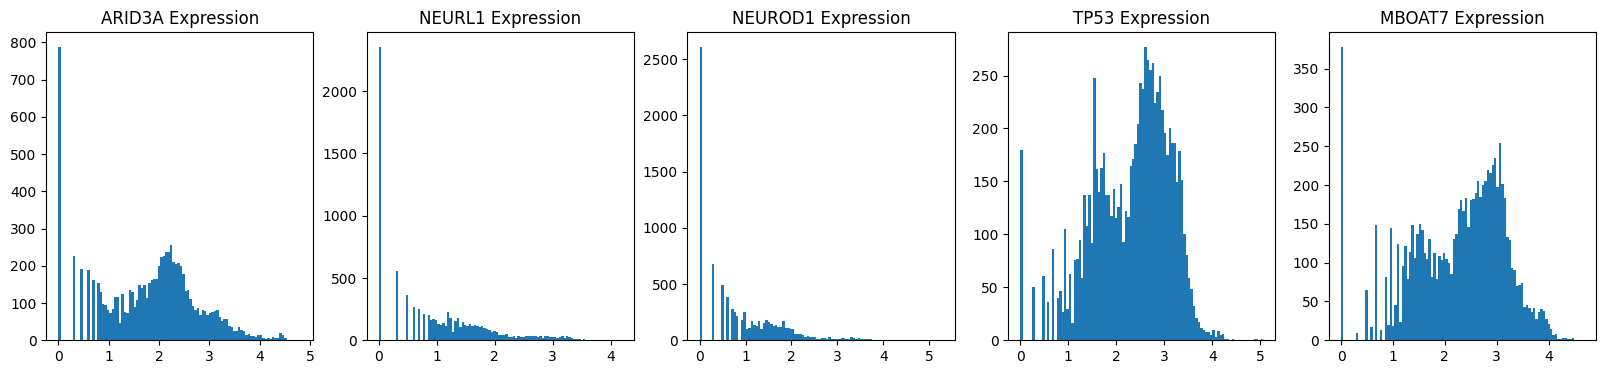

In [18]:
#look at a few y specific genes to determine male samples
import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=5, figsize = (20,4))

ax[0].hist(agg_exp['ARID3A'], bins = 100)
ax[0].set_title('ARID3A Expression')
ax[1].hist(agg_exp['NEURL1'], bins = 100)
ax[1].set_title('NEURL1 Expression')
ax[2].hist(agg_exp['NEUROD1'], bins = 100)
ax[2].set_title('NEUROD1 Expression')
ax[3].hist(agg_exp['TP53'], bins = 100)
ax[3].set_title('TP53 Expression')
ax[4].hist(agg_exp['MBOAT7'], bins = 100)
ax[4].set_title('MBOAT7 Expression')
plt.savefig('./data/Marker_gene_plots', dpi = 300)

In [19]:
agg_exp[agg_exp['ARID3A'] == 0].shape

(788, 29318)

In [20]:
agg_exp[agg_exp['NEURL1'] == 0].shape

(2353, 29318)

In [21]:
agg_exp[agg_exp['NEUROD1'] == 0].shape

(2609, 29318)

In [22]:
agg_exp[agg_exp['TP53'] == 0].shape

(180, 29318)

In [23]:
agg_exp[agg_exp['MBOAT7'] == 0].shape

(378, 29318)

# Extracting male and female samples

In [24]:
#refilter meta meta to samples subsequently removed by total count filtering
meta_subset = meta_subset.loc[agg_exp.index]

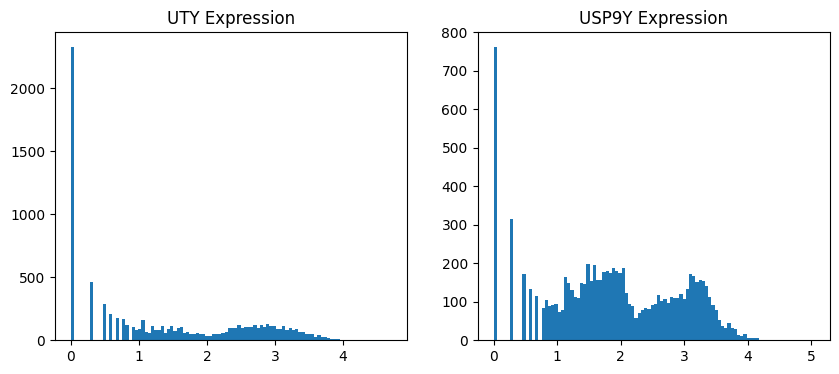

In [25]:
#look at a few y specific genes to determine male samples
import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize = (10,4))

ax[0].hist(agg_exp['UTY'], bins = 100)
ax[0].set_title('UTY Expression')
ax[1].hist(agg_exp['USP9Y'], bins = 100)
ax[1].set_title('USP9Y Expression')
plt.savefig('./data/MaleSpecificGenes', dpi = 300)

In [26]:
#male samples are those in which both male specific expression markers are greater than 0
male_samples = agg_exp[(agg_exp['UTY'] > 0) & (agg_exp['USP9Y'] > 0)]

In [27]:
#male samples are those in which both male specific expression markers are greater than 0
female_samples = agg_exp[(agg_exp['UTY'] == 0) & (agg_exp['USP9Y'] == 0)]

In [28]:
female_meta = meta_subset.loc[female_samples.index]
male_meta = meta_subset.loc[male_samples.index]
print(f'Female samples df has shape {female_meta.shape}')
print(f'Male samples df has shape {male_meta.shape}')
print(f'All samples df has shape {meta_subset.shape}')

Female samples df has shape (668, 9)
Male samples df has shape (6297, 9)
All samples df has shape (8717, 9)


In [29]:
#check that there are no samples that are in both
len(set(female_meta.index) & set(male_meta.index))

0

In [30]:
DATA_ROOT = '../data/Full data files'
female_meta.to_csv(f'{DATA_ROOT}/ARCHS4_female_healthy_meta.csv')
male_meta.to_csv(f'{DATA_ROOT}/ARCHS4_male_healthy_meta.csv')
meta_subset.to_csv(f'{DATA_ROOT}/ARCHS4_all_healthy_meta.csv')

In [31]:
#take the same 2 studies as the external dataset for male and female samples
#maximum list of study IDs taken as external: GSE128072, GSE96981, GSE128060

female_meta_external = female_meta[(female_meta['series_id'] == 'GSE128072') | (female_meta['series_id'] == 'GSE96981')]#| (female_meta['series_id'] == 'GSE128060')
male_meta_external = male_meta[(male_meta['series_id'] == 'GSE128072') | (male_meta['series_id'] == 'GSE96981')]#| (male_meta['series_id'] == 'GSE128060')]
female_meta_external

,title,characteristics_ch1,source_name_ch1,library_source,library_strategy,molecule_ch1,series_id,taxid_ch1,geo_accession
GSM3662836,B1_RNA-Seq [FGC1227_s_8_1_CTGAAGCT-GGCTCTGA],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662836
GSM3662837,B1_RNA-Seq [FGC1236_s_6_1_CTGAAGCT-GGCTCTGA],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662837
GSM3662838,B1_RNA-Seq [FGC1243_s_4_1_CTGAAGCT-GGCTCTGA],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662838
GSM3662840,B1_RNA-Seq [FGC1368_s_1_1_CTGAAGCT-GGCTCTGA],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662840
GSM3662841,B1_RNA-Seq [FGC1368_s_2_1_CTGAAGCT-GGCTCTGA],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662841
...,...,...,...,...,...,...,...,...,...
GSM3664122,MC-128_RNA-Seq [FGC1244_s_3_1_AGCGATAG-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664122
GSM3664123,MC-128_RNA-Seq [FGC1247_s_1_1_AGCGATAG-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664123
GSM3664124,MC-128_RNA-Seq [FGC1247_s_2_1_AGCGATAG-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664124
GSM3664125,MC-128_RNA-Seq [FGC1247_s_3_1_AGCGATAG-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664125


In [32]:
male_meta_external

,title,characteristics_ch1,source_name_ch1,library_source,library_strategy,molecule_ch1,series_id,taxid_ch1,geo_accession
GSM3662850,B2_RNA-Seq [FGC1368_s_3_1_CGCTCATT-GGCTCTGA],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662850
GSM3662852,B3_RNA-Seq [FGC1227_s_8_1_CGGCTATG-ATAGAGGC],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662852
GSM3662853,B3_RNA-Seq [FGC1236_s_6_1_CGGCTATG-ATAGAGGC],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662853
GSM3662854,B3_RNA-Seq [FGC1243_s_4_1_CGGCTATG-ATAGAGGC],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662854
GSM3662855,B3_RNA-Seq [FGC1243_s_5_1_CGGCTATG-ATAGAGGC],"cohort: penn cohort 1,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3662855
...,...,...,...,...,...,...,...,...,...
GSM3664097,MC-123_RNA-Seq [FGC1247_s_4_1_CGGCTATG-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664097
GSM3664098,MC-123_RNA-Seq [FGC1297_s_7_1_CGGCTATG-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664098
GSM3664099,MC-123_RNA-Seq [FGC1324_s_2_1_CGGCTATG-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664099
GSM3664106,MC-124_RNA-Seq [FGC1247_s_2_1_TCCGCGAA-GTACTGAC],"cohort: penn cohort 2,tissue: liver,individual...",liver,transcriptomic,RNA-Seq,total RNA,GSE128072,9606,GSM3664106


In [33]:
male_meta.series_id.value_counts()

series_id
GSE128072              713
GSE213621,GSE213623    342
GSE124076,GSE222593    313
GSE179250              192
GSE193066,GSE193084    148
                      ... 
GSE130073,GSE130075      1
GSE83115                 1
GSE81080,GSE81102        1
GSE88244                 1
GSE88121                 1
Name: count, Length: 328, dtype: int64

In [34]:
female_meta.series_id.value_counts()

series_id
GSE128072              367
GSE128060              190
GSE224901                9
GSE261432                8
GSE263614                7
GSE89775                 6
GSE143223                6
GSE167173                6
GSE247407                6
GSE144775                6
GSE70503                 6
GSE158485                4
GSE256141                4
GSE154377,GSE154378      3
GSE83322                 2
GSE63124                 2
GSE145728                2
GSE217708                2
GSE127964                2
GSE124528                1
GSE112330                1
GSE119630                1
GSE124395                1
GSE123498                1
GSE87487                 1
GSE63018                 1
GSE81928                 1
GSE81252                 1
GSE78296                 1
GSE59089,GSE59090        1
GSE88424                 1
GSE88393                 1
GSE138611                1
GSE193066,GSE193084      1
GSE178313                1
GSE160016,GSE160022      1
GSE157791         

In [35]:
pd.Series(meta_subset.index.isin(male_meta_external.index)).value_counts()

False    8004
True      713
Name: count, dtype: int64

In [36]:
# create a training dataset without the female and male external samples
meta_subset_stringent = meta_subset.loc[~meta_subset.index.isin(male_meta_external.index)]
meta_subset_stringent = meta_subset_stringent.loc[~meta_subset_stringent.index.isin(female_meta_external.index)]

In [37]:
meta_subset_stringent

,title,characteristics_ch1,source_name_ch1,library_source,library_strategy,molecule_ch1,series_id,taxid_ch1,geo_accession
GSM1101972,Liver,tissue: liver,biochain:r-1234149-p,transcriptomic,RNA-Seq,total RNA,GSE45326,9606,GSM1101972
GSM1377536,R-PHH-DMSO,tissue: liver,primary human hepatocytes,transcriptomic,RNA-Seq,total RNA,"GSE57227,GSE57312",9606,GSM1377536
GSM1377537,R-PHH-GW4064,tissue: liver,primary human hepatocytes,transcriptomic,RNA-Seq,total RNA,"GSE57227,GSE57312",9606,GSM1377537
GSM1416804,Normal_huLiver,"tissue: liver tissue,injury: none",normal human liver biopsy,transcriptomic,RNA-Seq,total RNA,GSE58679,9606,GSM1416804
GSM1427132,RNAseq_F-shNT_rep1,"tissue: fetal liver,cell type: cd34+ hspc-deri...",human primary fetal live proerythroblasts (pro...,transcriptomic,RNA-Seq,total RNA,"GSE59089,GSE59090",9606,GSM1427132
...,...,...,...,...,...,...,...,...,...
GSM9279098,"Isolated Human Hepatocytes, HH36, PNPLA3-WT","tissue: liver,genotype: wt",liver,transcriptomic,RNA-Seq,total RNA,GSE309786,9606,GSM9279098
GSM9279101,"Isolated Human Hepatocytes, 1, PNPLA3-I148M","tissue: liver,genotype: i148m",liver,transcriptomic,RNA-Seq,total RNA,GSE309786,9606,GSM9279101
GSM9279102,"Isolated Human Hepatocytes, HH002, PNPLA3-I148M","tissue: liver,genotype: i148m",liver,transcriptomic,RNA-Seq,total RNA,GSE309786,9606,GSM9279102
GSM9279103,"Isolated Human Hepatocytes, HH003, PNPLA3-I148M","tissue: liver,genotype: i148m",liver,transcriptomic,RNA-Seq,total RNA,GSE309786,9606,GSM9279103


In [38]:
DATA_ROOT = '../data/Full data files'
female_meta_external.to_csv(f'{DATA_ROOT}/ARCHS4_female_external_meta.csv')
male_meta_external.to_csv(f'{DATA_ROOT}/ARCHS4_male_external_meta.csv')
meta_subset_stringent.to_csv(f'{DATA_ROOT}/ARCHS4_withoutFMExternal_meta.csv')

In [39]:
#create a counts dataframe without the external samples
agg_exp_wo_external = agg_exp.loc[meta_subset_stringent.index]

In [40]:
agg_exp_wo_external

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,AAAS,AACS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
GSM1101972,1.518514,1.556303,1.255273,4.079145,1.690196,1.732394,1.431364,1.806180,1.892095,2.537819,...,1.851258,0.477121,2.225309,2.350248,2.281033,1.079181,3.155640,2.212188,3.052309,3.190892
GSM1377536,3.687172,1.732394,4.529879,4.711031,1.662758,1.113943,1.477121,2.322219,3.367729,3.354493,...,2.720986,2.648360,2.531479,3.769820,3.390228,2.803457,3.813848,4.344058,3.824776,3.502427
GSM1377537,3.739651,2.045323,4.278594,4.540380,1.681241,1.204120,1.799341,2.525045,3.260548,3.409426,...,2.640481,2.563481,2.531479,3.895588,3.393400,2.835056,3.703205,4.498214,3.726401,3.412461
GSM1416804,3.284882,1.414973,3.089198,3.873785,1.204120,0.301030,0.301030,1.113943,2.029384,1.518514,...,1.278754,1.301030,1.230449,2.605305,2.041393,0.778151,2.294466,2.567026,2.214844,2.037426
GSM1427132,1.255273,1.113943,0.000000,0.845098,0.301030,0.477121,0.000000,2.195900,3.264582,3.136086,...,3.067443,3.513883,1.643453,2.380211,2.927370,0.903090,2.894316,3.440122,3.213252,3.039414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM9279098,3.828918,1.698970,4.318939,4.672735,2.460898,1.301030,1.176091,1.204120,2.357935,2.354108,...,1.954243,1.079181,2.008600,2.848805,2.877371,2.287802,3.259833,2.352183,3.069298,2.987666
GSM9279101,3.561698,1.949390,4.068149,4.539503,2.033424,1.204120,2.029384,1.322219,2.434569,2.367356,...,1.857332,1.079181,1.897627,2.693727,2.866878,1.826075,3.159266,2.448706,2.979548,2.879669
GSM9279102,3.807467,1.863323,4.234998,4.704082,1.875061,1.462398,1.949390,1.342423,2.442480,2.394452,...,1.863323,1.698970,1.819544,2.748188,2.808886,1.991226,3.638190,2.552668,3.141450,2.984527
GSM9279103,3.580583,1.986772,4.092615,4.982579,1.826075,1.342423,1.342423,1.176091,2.519828,2.445604,...,1.924279,0.845098,1.690196,2.893762,2.806858,1.707570,3.248954,2.721811,3.106191,2.968483


In [41]:
male_external_expressions = agg_exp.loc[male_meta_external.index]
female_external_expressions = agg_exp.loc[female_meta_external.index]

In [42]:
female_external_expressions.to_csv(f'{DATA_ROOT}/ARCHS4_female_external_expressions.tsv', sep = '\t')

In [43]:
male_external_expressions.to_csv(f'{DATA_ROOT}/ARCHS4_male_external_expressions.tsv', sep = '\t')

In [44]:
agg_exp_wo_external

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,AAAS,AACS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
GSM1101972,1.518514,1.556303,1.255273,4.079145,1.690196,1.732394,1.431364,1.806180,1.892095,2.537819,...,1.851258,0.477121,2.225309,2.350248,2.281033,1.079181,3.155640,2.212188,3.052309,3.190892
GSM1377536,3.687172,1.732394,4.529879,4.711031,1.662758,1.113943,1.477121,2.322219,3.367729,3.354493,...,2.720986,2.648360,2.531479,3.769820,3.390228,2.803457,3.813848,4.344058,3.824776,3.502427
GSM1377537,3.739651,2.045323,4.278594,4.540380,1.681241,1.204120,1.799341,2.525045,3.260548,3.409426,...,2.640481,2.563481,2.531479,3.895588,3.393400,2.835056,3.703205,4.498214,3.726401,3.412461
GSM1416804,3.284882,1.414973,3.089198,3.873785,1.204120,0.301030,0.301030,1.113943,2.029384,1.518514,...,1.278754,1.301030,1.230449,2.605305,2.041393,0.778151,2.294466,2.567026,2.214844,2.037426
GSM1427132,1.255273,1.113943,0.000000,0.845098,0.301030,0.477121,0.000000,2.195900,3.264582,3.136086,...,3.067443,3.513883,1.643453,2.380211,2.927370,0.903090,2.894316,3.440122,3.213252,3.039414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM9279098,3.828918,1.698970,4.318939,4.672735,2.460898,1.301030,1.176091,1.204120,2.357935,2.354108,...,1.954243,1.079181,2.008600,2.848805,2.877371,2.287802,3.259833,2.352183,3.069298,2.987666
GSM9279101,3.561698,1.949390,4.068149,4.539503,2.033424,1.204120,2.029384,1.322219,2.434569,2.367356,...,1.857332,1.079181,1.897627,2.693727,2.866878,1.826075,3.159266,2.448706,2.979548,2.879669
GSM9279102,3.807467,1.863323,4.234998,4.704082,1.875061,1.462398,1.949390,1.342423,2.442480,2.394452,...,1.863323,1.698970,1.819544,2.748188,2.808886,1.991226,3.638190,2.552668,3.141450,2.984527
GSM9279103,3.580583,1.986772,4.092615,4.982579,1.826075,1.342423,1.342423,1.176091,2.519828,2.445604,...,1.924279,0.845098,1.690196,2.893762,2.806858,1.707570,3.248954,2.721811,3.106191,2.968483


In [45]:
agg_exp_wo_external.to_csv(f'{DATA_ROOT}/ARCHS4_healthy_log_noFMExternal.tsv', sep = '\t')